In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
username = "manikya.pant"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Age                     200 non-null    float64
 2   Annual Income (k$)      200 non-null    float64
 3   Spending Score (1-100)  200 non-null    float64
 4   Genre_Male              200 non-null    bool   
dtypes: bool(1), float64(3), int64(1)
memory usage: 6.6 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     200 non-null    float64
 1   Annual Income (k$)      200 non-null    float64
 2   Spending Score (1-100)  200 non-null    float64
 3   Genre_Male              200 non-null    bool   
dtypes: bool(1), float64(3)
memory usag

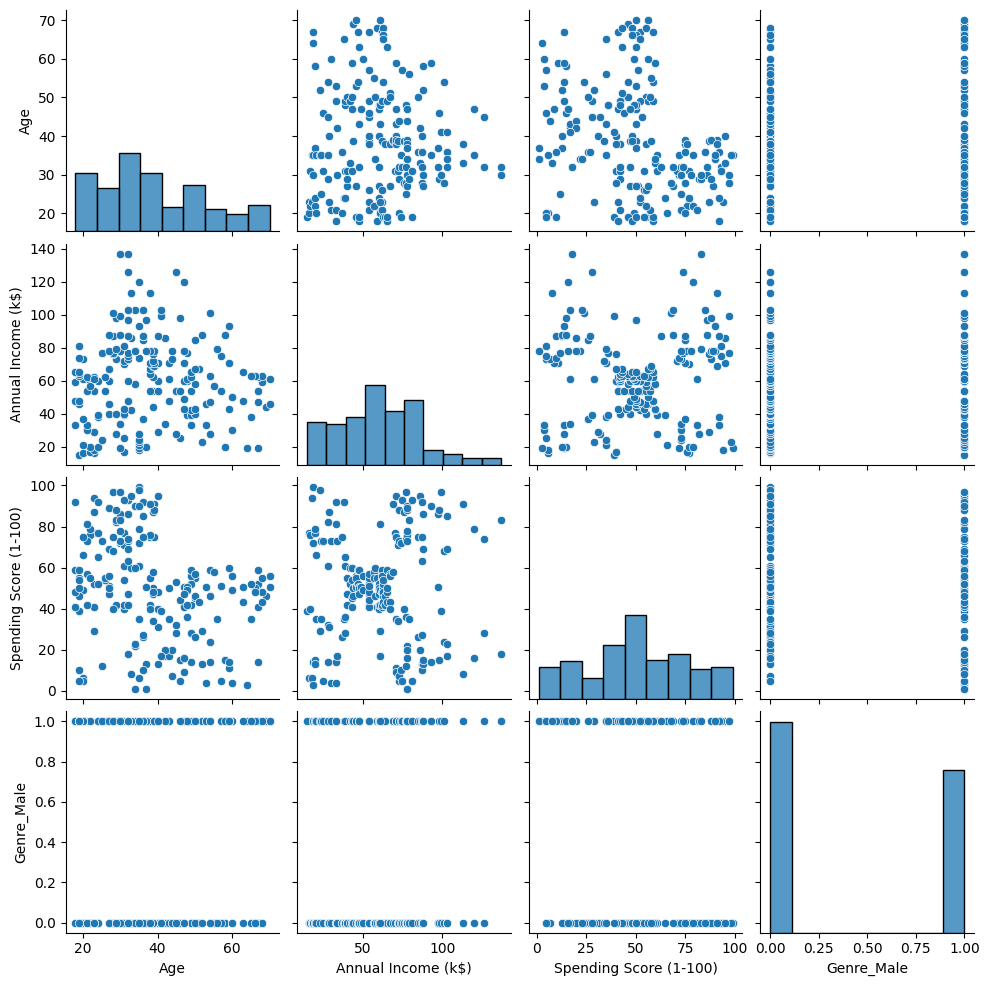

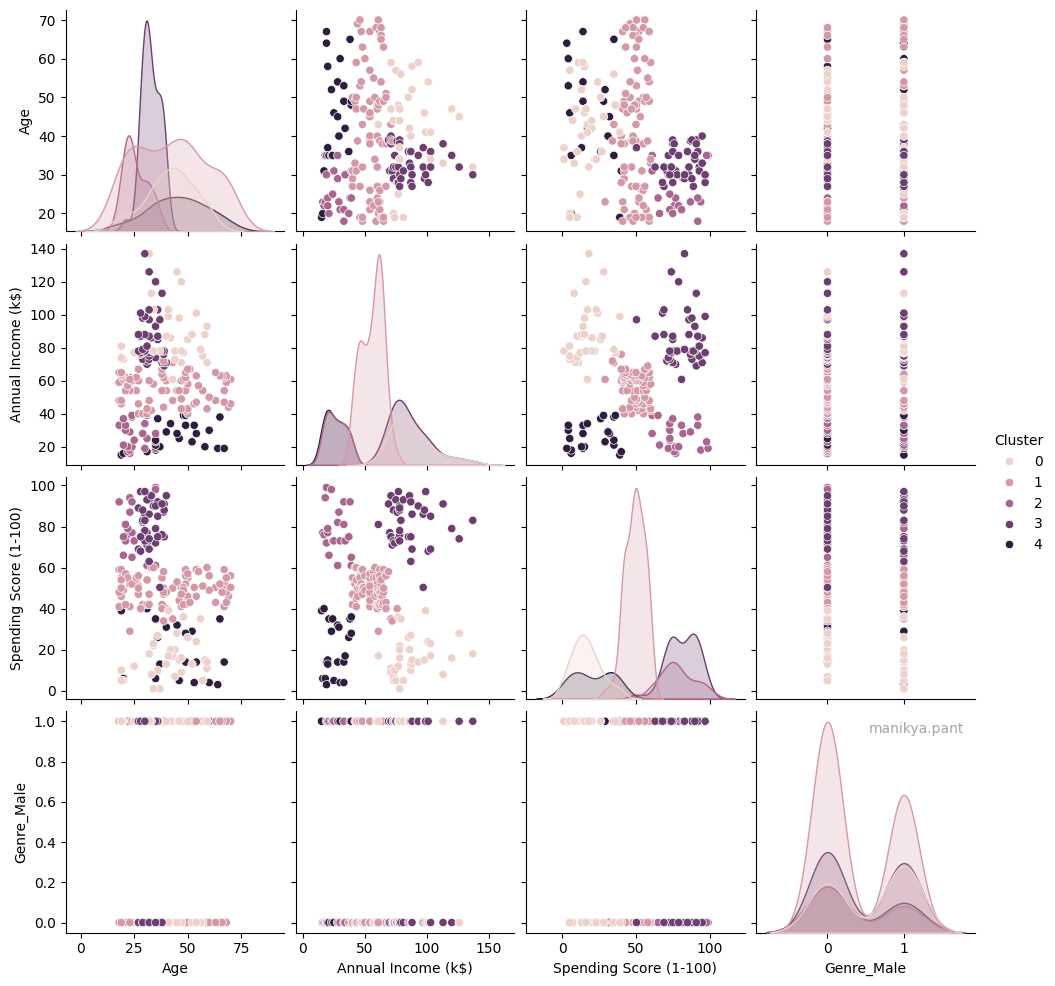

In [32]:
class KMeans:
    def __init__(self, n_clusters=3, max_iters=100000, tol=1e-4):
        """
        n_clusters: Number of clusters
        max_iters: Maximum number of iterations
        tol: Tolerance to declare convergence
        """
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
    
    def fit(self, X):
        #Initialize random centroids from the datas within
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        # Need to find the closest centroid for each point
        # Will do till it converges or max_iters is reached

        for i in range(self.max_iters):
            # Assign clusters
            distances = self._compute_distances(X)
            labels = np.argmin(distances, axis=1)

            # Store old centroids for convergence check
            old_centroids = self.centroids.copy()

            # Update centroids
            for k in range(self.n_clusters):
                if np.any(labels == k):  # Avoid empty clusters
                    self.centroids[k] = X[labels == k].mean(axis=0)

            # Check for convergence
            if np.linalg.norm(self.centroids - old_centroids) < self.tol:
                break

    def _compute_distances(self, X):
        # Compute the distance from each point to each centroid
        return np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
    
    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)
    
    def getCost(self, X):
        distances = self._compute_distances(X)
        labels = np.argmin(distances, axis=1)
        cost = 0
        for k in range(self.n_clusters):
            cost += np.sum((X[labels == k] - self.centroids[k]) ** 2)
        return cost
    



df = pd.read_csv('Clustering_dataset(in).csv')
# print(df.head())
# print(df.shape)
# print(df.info())

# clean the data
# changing numeric colums to mean for missing values and categorical to mode
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].mean())

df = pd.get_dummies(df, drop_first=True)
print(df.info())


# can drop the customer ID column as it is not useful for clustering
df = df.drop('CustomerID', axis=1)
print(df.info())


# visulaizing the data, for each column as scatter between each other
sns.pairplot(df)
plt.show()






# apply KMeans
kmeans = KMeans(n_clusters=5, max_iters=100000, tol=1e-4)
kmeans.fit(df.astype(float).values)
labels = kmeans.predict(df.astype(float).values)
cost = kmeans.getCost(df.astype(float).values)


# trying to visualize the clusters by pair plots
df['Cluster'] = labels
sns.pairplot(df, hue='Cluster', diag_kind='kde')
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()







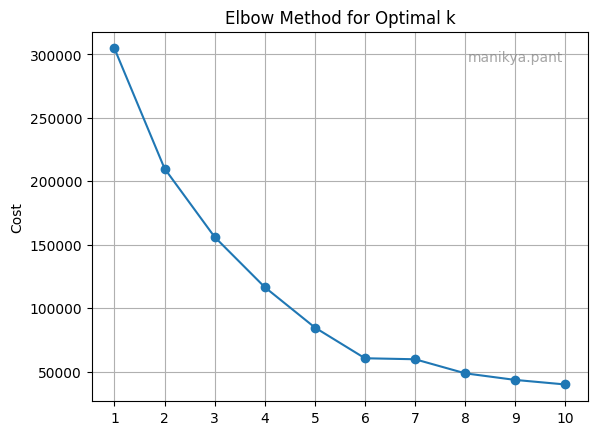

In [33]:
# trying with different number of clusters and plotting the cost
costs = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, max_iters=100000, tol=1e-4)
    kmeans.fit(df.drop('Cluster', axis=1).astype(float).values)
    cost = kmeans.getCost(df.drop('Cluster', axis=1).astype(float).values)
    costs.append(cost)

# plotting cost vs k
plt.plot(range(1, 11), costs, marker='o')
plt.ylabel('Cost')
plt.title('Elbow Method for Optimal k')
plt.xticks(range(1, 11))
plt.grid()
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

Average Silhouette Score for k=2: 0.2964992243871604
Average Silhouette Score for k=3: 0.382763199532068
Average Silhouette Score for k=4: 0.334812935652565
Average Silhouette Score for k=5: 0.42080105547522256
Average Silhouette Score for k=6: 0.450418964103701
Average Silhouette Score for k=7: 0.4099599077019816
Average Silhouette Score for k=8: 0.4411596915589595
Average Silhouette Score for k=9: 0.40241475005065924
Average Silhouette Score for k=10: 0.3779535454498415


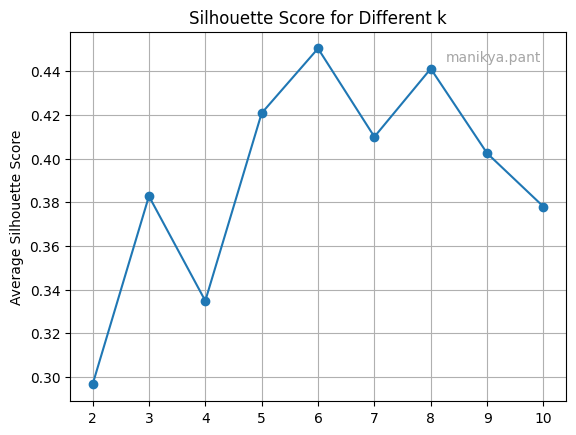

In [34]:
# finding the silhouette score for different k
avg_silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, max_iters=100000, tol=1e-4)
    kmeans.fit(df.drop('Cluster', axis=1).astype(float).values)
    labels = kmeans.predict(df.drop('Cluster', axis=1).astype(float).values)
    
    # Calculate silhouette score
    silhouette_scores = []
    for i in range(len(df)):
        same_cluster = df.drop('Cluster', axis=1).values[labels == labels[i]]
        other_clusters = df.drop('Cluster', axis=1).values[labels != labels[i]]
        
        if len(same_cluster) > 1:
            a = np.mean(np.linalg.norm(same_cluster.astype(float) - df.drop('Cluster', axis=1).astype(float).values[i], axis=1))
        else:
            a = 0
        
        if len(other_clusters) > 0:
            b = np.min([np.mean(np.linalg.norm(df.drop('Cluster', axis=1).astype(float).values[labels == j] - df.drop('Cluster', axis=1).astype(float).values[i], axis=1)) for j in np.unique(labels) if j != labels[i]])
        else:
            b = 0
        
        silhouette_score = (b - a) / max(a, b) if max(a, b) > 0 else 0
        silhouette_scores.append(silhouette_score)
    
    avg_silhouette_score = np.mean(silhouette_scores)
    avg_silhouette_scores.append(avg_silhouette_score)
    print(f'Average Silhouette Score for k={k}: {avg_silhouette_score}')

    # plotting average silhouette score vs k
plt.plot(range(2, 11), avg_silhouette_scores, marker='o')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.xticks(range(2, 11))
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.grid()


Through both elbow method and silhoutte method the optimal number of clusters is 6
Adding clusters beyond it is like point of diminishing returns
